# Agrupando colores
Vamos a crear imágenes con una cantidad fija de colores usando K-Means.

#### 1. Importa las librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imsave
from sklearn.cluster import KMeans
from PIL import Image

#### 2. Lee la imagen

In [2]:
img = np.array(Image.open("imagen.png").convert("RGB"))

In [4]:
print("Tamaño de la imagen:", img.shape)

Tamaño de la imagen: (500, 367, 3)


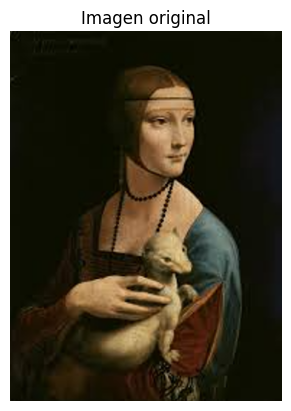

In [ ]:
plt.imshow(img) # muestro la imagen original
plt.axis("off")
plt.title("Imagen original")

#### 3. Modifica la estructura de la imagen
 →  — cada fila es un pixel

In [7]:
forma_original = img.shape # guardo la forma original para luego reconstruir la imagen
X = img.reshape(-1, 3).astype(float) # convierto la imagen a una matriz de píxeles (cada fila es un píxel con sus valores RGB)
print("Tamaño para KMeans:", X.shape) # imprimo el tamaño de la matriz para KMeans

Tamaño para KMeans: (183500, 3)


#### 4. K-Means
K = número de colores que queremos en la imagen de salida

In [ ]:
n_colores = 8 # número de colores que queremos en la imagen segmentada

km = KMeans(n_clusters=n_colores, random_state=42, n_init=10) # creo el modelo KMeans con el número de colores deseado
km.fit(X) # entreno el modelo con los datos de los píxeles

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


#### 5. Sustituye cada pixel por su centroide
 indica a qué cluster pertenece cada pixel.  tiene el color (RGB) de cada centroide.

In [ ]:
# para cada píxel, obtengo el color (RGB) del centroide de su cluster
imagen_nueva = km.cluster_centers_[km.labels_] 

#### 6. Restaura la forma original

In [10]:
# restauro la forma original (alto, ancho, 3) y convierto a enteros de 8 bits para que matplotlib pueda mostrarla
imagen_nueva = imagen_nueva.reshape(forma_original).astype(np.uint8)

#### 7. Muestra y guarda la imagen resultante

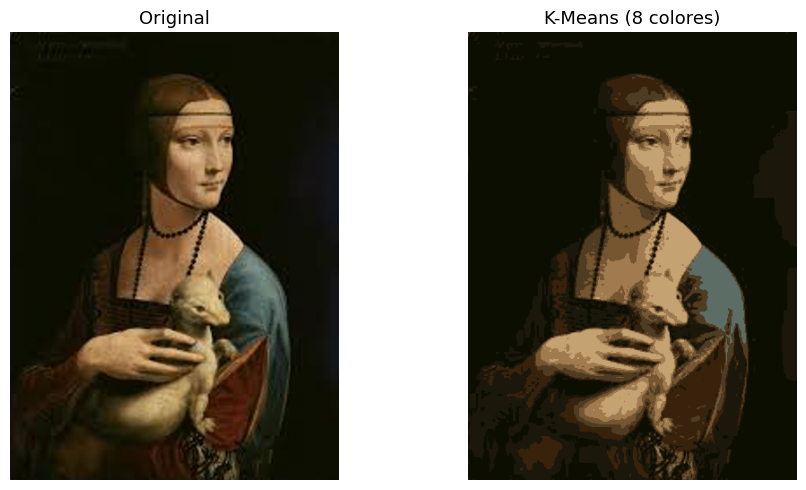

In [11]:
# muestro la imagen original y la segmentada con KMeans
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title("Original", fontsize=13)
axes[0].axis("off")
axes[1].imshow(imagen_nueva)
axes[1].set_title(f"K-Means ({n_colores} colores)", fontsize=13)
axes[1].axis("off")
plt.tight_layout()
plt.show()

# guardo la imagen segmentada en un nuevo archivo
imsave("imagen_kmeans.png", imagen_nueva) 

#### 8. Función que encapsula todo el proceso

Guardada en: imagen_8colores.png


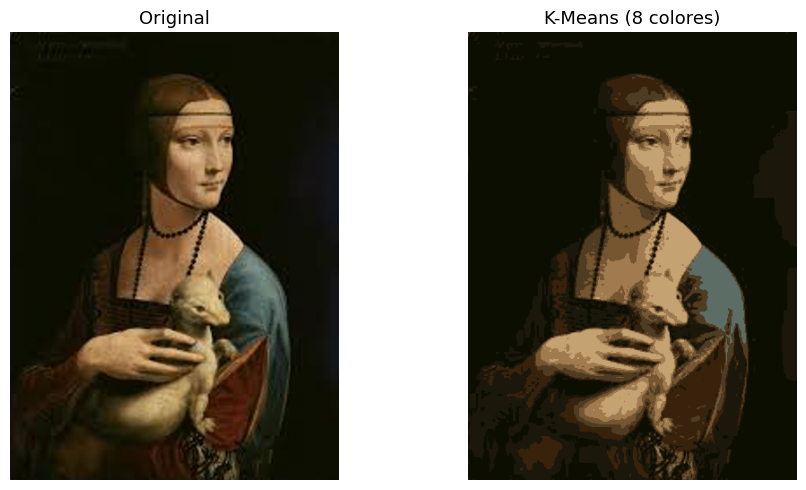

In [15]:
def reducir_colores(ruta_imagen, n_colores, guardar=False, mostrar=True):
   
    # cargo la imagen
    img = np.array(Image.open(ruta_imagen).convert("RGB"))
    forma_original = img.shape

    # cambio tamaño y entreno con KMeans
    X = img.reshape(-1, 3).astype(float)
    km = KMeans(n_clusters=n_colores, random_state=42, n_init=10)
    km.fit(X)

    # reconstruyo la imagen segmentada
    imagen_nueva = km.cluster_centers_[km.labels_]
    imagen_nueva = imagen_nueva.reshape(forma_original).astype(np.uint8)

    if guardar: # si se indica guardar, creo un nuevo nombre de archivo añadiendo el número de colores y guardo la imagen segmentada
        ruta_salida = ruta_imagen.replace(".", f"_{n_colores}colores.")
        imsave(ruta_salida, imagen_nueva)
        print(f"Guardada en: {ruta_salida}")

    if mostrar: # si se indica mostrar, muestro la imagen original y la segmentada con KMeans
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img)
        axes[0].set_title("Original", fontsize=13)
        axes[0].axis("off")
        axes[1].imshow(imagen_nueva)
        axes[1].set_title(f"K-Means ({n_colores} colores)", fontsize=13)
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()

    return imagen_nueva # devuelvo la imagen segmentada como un array de NumPy


# ejemplo de uso de la función para reducir los colores de una imagen a 8, guardar el resultado y mostrar ambas imágenes
reducir_colores("imagen.png", n_colores=8, guardar=True, mostrar=True);

Guardada en: tango_10colores.jpg


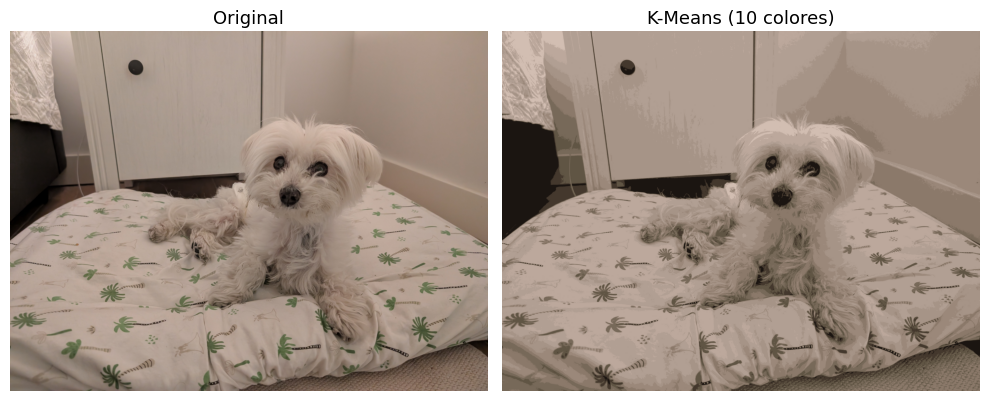

In [ ]:
# pruebo la función con una imagen y 10 colores
reducir_colores("tango.jpg", n_colores=10, guardar=True, mostrar=True);

Guardada en: dina_3colores.jpg


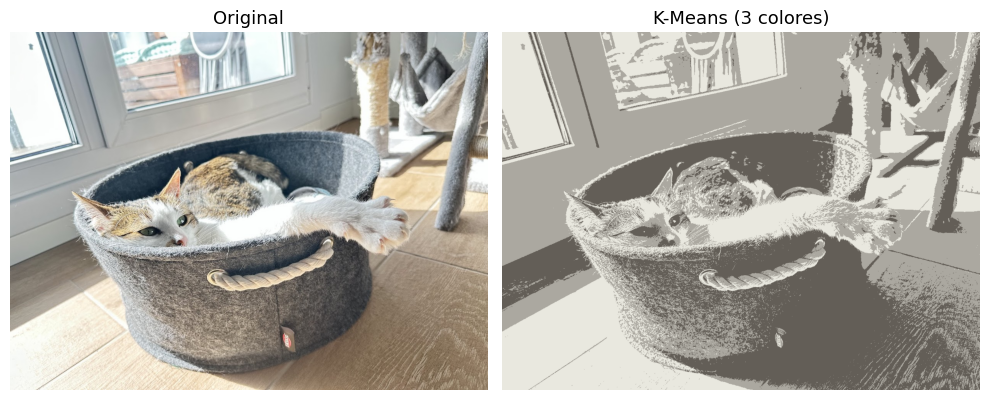

In [ ]:
# pruebo la función con otra imagen y 3 colores
reducir_colores("dina.jpg", n_colores=3, guardar=True, mostrar=True); 